# 04 — ML surrogate model (fast approximation)

Train a machine learning model to approximate the analytical pricing function and benchmark prediction speed.

## Correspondence with the paper
- ML approximation of pricing function
- Generalization on held-out test set
- Motivation: repeated pricing at scale

## Outputs
- MAE/RMSE/R²
- Predicted vs true plot
- Inference timing benchmark

In [4]:
import sys
import os

# Add project root to Python path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project root added:", project_root)

Project root added: c:\Users\rayzu\Pictures\fx-option-pricing-ml


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from src.bs_fx import garman_kohlhagen_price
from src.ml_model import train_surrogate_rf, evaluate_model, benchmark_inference

rng = np.random.default_rng(1)
n = 40_000

S = rng.uniform(0.8, 1.4, n)
K = rng.uniform(0.8, 1.4, n)
T = rng.uniform(0.05, 2.0, n)
rd = rng.uniform(0.0, 0.06, n)
rf = rng.uniform(0.0, 0.06, n)
sigma = rng.uniform(0.05, 0.50, n)

y = garman_kohlhagen_price(S, K, T, rd, rf, sigma, option="call")

X = pd.DataFrame({"S": S, "K": K, "T": T, "rd": rd, "rf": rf, "sigma": sigma})
y = pd.Series(y, name="call_price")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
model, train_s = train_surrogate_rf(X_train, y_train, n_estimators=400)
pred, metrics = evaluate_model(model, X_test, y_test)

print("Train seconds:", train_s)
print(metrics)

import json

metrics_full = {
    "train_seconds": train_s,
    "MAE": metrics["MAE"],
    "RMSE": metrics["RMSE"],
    "R2": metrics["R2"]
}

with open("../results/metrics/ml_metrics.json", "w") as f:
    json.dump(metrics_full, f, indent=4)

Train seconds: 9.12159276008606
{'MAE': 0.008202326355081717, 'RMSE': 0.011748900146337159, 'R2': 0.9928190927978595}


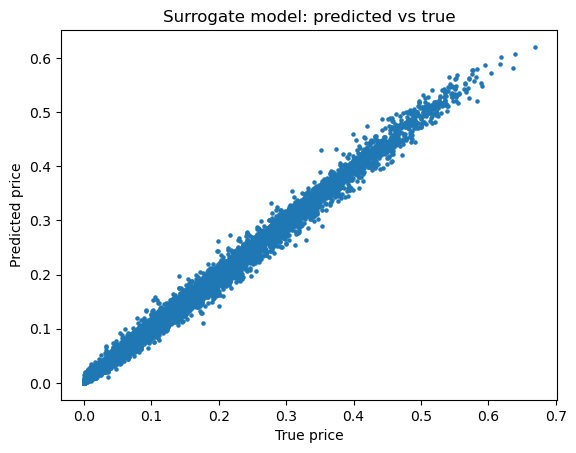

In [7]:
plt.figure()
plt.scatter(y_test, pred, s=5)
plt.xlabel("True price")
plt.ylabel("Predicted price")
plt.title("Surrogate model: predicted vs true")
plt.savefig("../results/figures/ml_pred_vs_true.png", dpi=300)
plt.show()

In [8]:
t_inf = benchmark_inference(model, X_test, n_samples=10000)
print("Inference time (10k samples):", t_inf, "seconds")

with open("../results/metrics/ml_inference_time.txt", "w") as f:
    f.write(f"Inference time (10k samples): {t_inf} seconds\n")

Inference time (10k samples): 0.14166688919067383 seconds


In [9]:
X.to_csv("../data/fx_synthetic_features.csv", index=False)
y.to_csv("../data/fx_synthetic_targets.csv", index=False)

# Discussion

The ML surrogate model approximates the analytical pricing function with very low error.

## Key observations

- High R² confirms strong functional learning.
- Inference time is significantly faster than Monte Carlo.
- Model generalizes well across parameter space.

## Interpretation

Machine learning does not replace the analytical model,
but provides a fast approximation for repeated evaluations.

## Limitations

- Extrapolation outside training domain is unsafe.
- Model lacks economic interpretability.
- Training cost may be significant.

## Perspective

Future work could explore:
- Neural networks
- Physics-informed ML
- Hybrid models combining theory and learning

## Reproducibility

All experiments were performed with:
- Random seed fixed
- Deterministic splits
- Explicit parameter ranges

This ensures full reproducibility of the results.